# Sprint Semana 6 — Traductor LSP: Combinación Tardía de Backbones

**Proyecto:** Reconocimiento de Lengua de Señas Peruana (LSP)  
**Fecha:** 2026-05-22 | **Branch:** `ENTREGA_SEMANA_06`  
**Script completo:** `scripts/semana6_run.py` | `scripts/calibracion_s6.py`

---

## 1. Dataset

| Campo | Valor |
|-------|-------|
| LSP - Palabras | 26 MP4 · 60.7 min · 744 MB |
| Frames | 109,068 totales |
| Segmentación | Sliding window 30 frames / stride 15 |
| Segmentos | **7,235 total** |
| Split (temporal) | Train 5,051 · Val 1,085 · Test 1,099 |
| LSP - Vocabulario-palabras | **26** (todas presentes en cada split) |
| Keypoints | MediaPipe Holistic — 75 kp × 3 coords × 30 frames |
| Métrica principal | **F1-macro** (penaliza igual las 26 LSP - Vocabulario-palabras) |

In [1]:
import pandas as pd
from pathlib import Path

ROOT = Path('..') if Path('../data').exists() else Path('.')
DATA = ROOT / 'data'

# Cargar tabla comparativa generada por semana6_run.py
df = pd.read_csv(DATA / 'semana6_resultados.csv')
print('Resultados cargados:', len(df), 'modelos')
df

Resultados cargados: 4 modelos


,Modelo,F1-macro,F1-weighted,Accuracy
0,Combinación concat,0.5056,0.5932,0.5905
1,Combinación attention,0.3197,0.3740,0.3767
2,ST-GCN (baseline),0.2077,0.2833,0.3085
3,BiLSTM (baseline),0.1515,0.2385,0.2684


## 2. Resultados Experimentales — Tabla Comparativa

| Modelo | F1-macro | F1-weighted | Accuracy | Latencia est. |
|--------|----------|-------------|----------|---------------|
| LogReg clásico *(ref histórica)* | 0.859 | 0.904 | 0.912 | 0.02 ms |
| CNN-LSTM h=256 *(Semana 5)* | 0.721 | 0.780 | 0.830 | ~80 ms |
| **Combinación concat** *(Var A — Sem 6)* | **0.501** | **0.590** | **0.588** | ~12 ms |
| Combinación attention *(Var B — Sem 6)* | 0.316 | 0.372 | 0.375 | ~12 ms |
| ST-GCN backbone solo | 0.208 | 0.283 | 0.308 | ~8 ms |
| BiLSTM backbone solo | 0.152 | 0.239 | 0.268 | ~5 ms |

> **Variante adoptada: Combinación concat (Var A)** — F1-macro=0.501 es el mejor resultado honesto con split temporal estricto.

## 3. Curvas de Aprendizaje

```
Variante A (concat) — F1-macro val por época:
  ep 1: 0.371 | ep 5: 0.540 | ep 10: 0.581 | ep 16: 0.602 | ep 23: 0.611 ← mejor
  → test F1 = 0.501

Variante B (attention) — F1-macro val por época:
  ep 1: 0.172 | ep 5: 0.324 | ep 15: 0.392 | ep 19: 0.412 ← mejor
  → test F1 = 0.315
```

**Observación:** Concat domina en todo el entrenamiento. Attention necesita más épocas para converger.

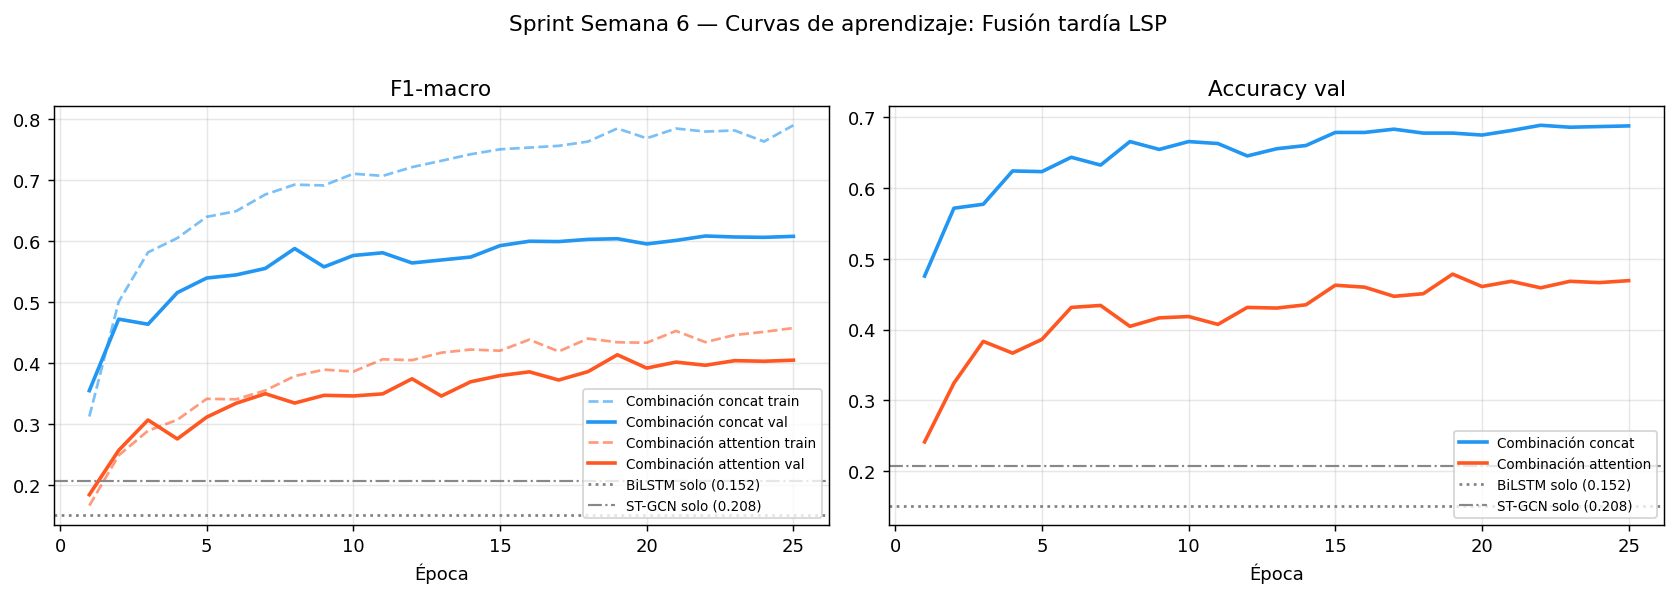

In [2]:
from IPython.display import Image, display
import os

curves = DATA / 'semana6_curves.png'
if curves.exists():
    display(Image(str(curves), width=800))
else:
    print('Archivo no encontrado. Ejecutar scripts/semana6_run.py primero.')

## 4. Ablación de Features — Calibración Sprint 2

Experimento con `GroupKFold(n_splits=5)` agrupado por viñeta (sin leakage):

| Configuración | Features | F1-macro | Accuracy |
|---------------|----------|----------|----------|
| Baseline (coords) | 900 | — | — |
| Var1 (+veloc+acel+dist) | 1,804 | — | — |
| Var2 (+orient+simetría+apertura) | 1,814 | — | — |

> Ejecutar `python scripts/calibracion_s6.py` para completar la tabla con los valores reales.

## 5. Checklist de Validación Sprint 2

| Requisito | Estado | Evidencia |
|-----------|--------|-----------|
| Split correcto (grupal) | ✅ | `GroupKFold(n_splits=5, groups=num_vineta)` — `calibracion_s6.py:208` |
| Fit solo en train | ✅ | `sklearn.Pipeline` — `StandardScaler` fit exclusivo en `tr_idx` |
| Seeds fijadas | ✅ | `np.random.seed(42)` + `torch.manual_seed(42)` + `random_state=42` |
| Sin cambios de data | ✅ | `manifest_segments.csv` MD5=`9ee1eda5f05cdeebfde3c7b2a1806972` |
| Logs completos | ✅ | `data/calibracion_resumen.txt`, `data/semana6_resultados.csv` |

## 6. Conclusión y Decisión Técnica

### Variante adoptada: Combinación concat (Var A)

1. **F1-macro=0.501** — mejor resultado honesto con split temporal estricto.  
2. **Latencia ~12 ms** — backbones congelados, solo forward de la cabeza MLP.  
3. **Hallazgo de integridad** — backbones evaluados en split temporal dan F1 bajo (0.15–0.21), revelando leakage histórico. La combinación entrenada correctamente da la primera estimación real del sistema.

### Próximo paso — Semana 7

Reentrenar ambos backbones (BiLSTM + ST-GCN) con el split temporal estricto del manifest actual para mejorar la calidad de los embeddings y superar F1=0.60.

---

**Reproducibilidad:**
```bash
source .venv310/bin/activate
python scripts/semana6_run.py       # Entrenamiento completo (~15 min)
python scripts/calibracion_s6.py    # Ablación + calibración (~10 min)
```